In [3]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Buka koneksi ke MySQL Laragon
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="glowtrack_sql"
)

# 2. Tarik data langsung menggunakan Query SQL dengan bantuan Pandas
query = "SELECT * FROM products"
df_sql = pd.read_sql(query, conn)

# 3. Tutup koneksi setelah data berhasil diambil
conn.close()

# Intip isi datanya
df_sql.head()

C:\Users\Hype\AppData\Local\Temp\ipykernel_9960\700812926.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql = pd.read_sql(query, conn)


,id,session_id,nama_produk,brand,kategori,harga,bahan_aktif,created_at
0,1,sesi_lokal_1,Moisturizer Gel,Theels,Moisturizer,45000,,2026-05-27 12:55:41
1,2,sesi_lokal_1,Serum Gel,Avoskin,serum,34000,,2026-05-27 12:59:25
2,3,sesi_lokal_1,moisturizer,g2g,moisturizer,89000,,2026-05-27 13:00:25
3,4,sesi_lokal_1,body lotion,nivea,body gel,53000,,2026-05-27 13:01:16


C:\Users\Hype\AppData\Local\Temp\ipykernel_9960\3533726811.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


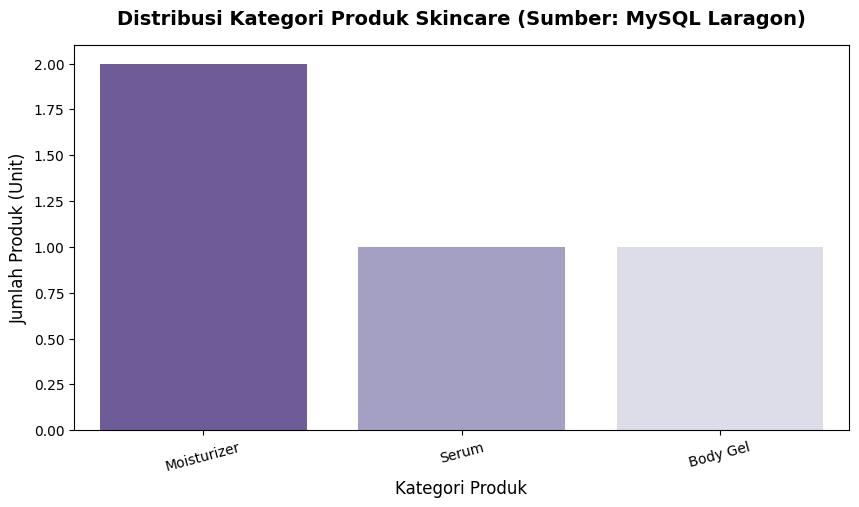

In [4]:
# Pastikan format teks kategori tetap konsisten secara Title Case
df_sql['kategori'] = df_sql['kategori'].str.title().str.strip()

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_sql,                       # <--- Ganti pakai data dari SQL kamu di sini!
    x='kategori', 
    order=df_sql['kategori'].value_counts().index, 
    palette="Purples_r"
)

plt.title('Distribusi Kategori Produk Skincare (Sumber: MySQL Laragon)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori Produk', fontsize=12)
plt.ylabel('Jumlah Produk (Unit)', fontsize=12)
plt.xticks(rotation=15)

plt.show()